# 🚗 Vehicle Telematics — Fuel Efficiency & Speed Zone Analysis
## Exploratory Data Analysis (EDA)

**Project Goal:**
> Build an optimal speed-efficiency map per vehicle and calculate total fuel consumption from real OBD sensor data.

**Dataset:** LEVIN Vehicle Telematics (Yun Solutions) — 16 vehicles, 3 months of real OBD data  
**Key Sensors:** OBD speed, KPL (fuel efficiency), RPM, engine load, coolant temp, throttle position  
**Author:** Paşan Sancak · [LinkedIn](https://linkedin.com/in/pasansancak) · [GitHub](https://github.com/pasansancak)

---
### Roadmap
1. Setup & Load
2. Data Cleaning
3. Sensor Distributions
4. Temporal Patterns
5. Speed-Efficiency Map (per vehicle)
6. Fleet Fuel Consumption Summary
7. Gear Estimation Analysis (per vehicle)
8. Data Quality Flags & Key Findings

## 0. Setup

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
import os
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['font.family'] = 'monospace'
sns.set_theme(style='darkgrid', palette='muted')

os.makedirs('../outputs', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)

print('Setup complete ✓')

Setup complete ✓


## 1. Load Data

In [49]:
df = pd.read_csv('../data/allcars.csv', low_memory=False)

# Force all sensor columns to numeric
# Some rows contain repeated header strings due to dataset concatenation issues
# errors='coerce' silently converts non-numeric strings to NaN
numeric_cols = ['tripID','deviceID','gps_speed','battery','cTemp','dtc',
                'eLoad','iat','imap','kpl','maf','rpm','speed','tAdv','tPos']

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Parse timestamp
df['timeStamp'] = pd.to_datetime(df['timeStamp'], errors='coerce')

# Drop rows where core sensor columns are NaN (corrupted header rows become NaN after coerce)
df = df.dropna(subset=['gps_speed', 'rpm', 'eLoad', 'kpl']).reset_index(drop=True)

print(f'Shape     : {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Devices   : {sorted(df["deviceID"].dropna().unique().astype(int).tolist())}')
print(f'Trips     : {df["tripID"].nunique()}')
print(f'Date range: {df["timeStamp"].min()} -> {df["timeStamp"].max()}')
df.head(3)

Shape     : 3,120,240 rows x 17 columns
Devices   : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 16]
Trips     : 431
Date range: 2017-11-18 16:23:30 -> 2018-01-31 23:18:50


,tripID,deviceID,timeStamp,accData,gps_speed,battery,cTemp,dtc,eLoad,iat,imap,kpl,maf,rpm,speed,tAdv,tPos
0,1.0,0.0,2017-12-22 18:43:05,10c0f8e00448fa18c80515d30000000000000000000000...,24.2612,0.0,66.0,0.0,28.6275,40.0,97.0,0.0,0.0,1010.75,23.0,0.0,0.0
1,1.0,0.0,2017-12-22 18:43:06,1138f8c804780a1ebdf718bcf919d10617c8e301b31017...,23.1500,0.0,66.0,0.0,33.7255,40.0,98.0,0.0,0.0,815.50,21.0,0.0,0.0
2,1.0,0.0,2017-12-22 18:43:07,10f0f89804480612c30010c30714ce0520b7f41dbdf118...,18.7052,0.0,66.0,0.0,43.1373,40.0,98.0,0.0,0.0,862.25,17.0,0.0,0.0


## 2. Data Cleaning

In [50]:
raw_len = len(df)

# Use OBD speed instead of GPS speed
# GPS speed has outliers up to 512 km/h due to signal glitches
# OBD speed column is more reliable (max 149 km/h in raw data)
df = df[df['speed'].between(0, 150)]

# Engine load: valid OBD range is 0-100%
df = df[df['eLoad'].between(0, 100)]

# KPL: remove sensor spikes — realistic max ~25 km/L for passenger vehicles
# Note: Vehicle 9 consistently shows higher values — likely different vehicle type/engine
df = df[df['kpl'].between(0, 25)]

# RPM: realistic operating range for passenger car engine
df = df[df['rpm'].between(0, 7000)]

# Coolant temperature: valid engine operating range
if 'cTemp' in df.columns:
    df['cTemp'] = df['cTemp'].where(df['cTemp'].between(-10, 130), np.nan)

# Sort chronologically within each vehicle-trip for time-series calculations
df = df.sort_values(['deviceID', 'tripID', 'timeStamp']).reset_index(drop=True)

# Flag vehicles with no KPL data — sensor not available or not recording
kpl_by_device = df.groupby('deviceID')['kpl'].sum()
NO_KPL_DEVICES = kpl_by_device[kpl_by_device == 0].index.tolist()

# Flag Vehicle 7 explicitly — kpl sensor is intermittent and unreliable
UNRELIABLE_KPL_DEVICES = [7.0]

print(f'Rows removed      : {raw_len - len(df):,} ({(raw_len-len(df))/raw_len*100:.1f}%)')
print(f'Clean shape       : {df.shape}')
print(f'No KPL data       : Vehicles {[int(d) for d in NO_KPL_DEVICES]}')
print(f'Unreliable KPL    : Vehicles {[int(d) for d in UNRELIABLE_KPL_DEVICES]}')
print(f'\n⚠ Vehicle 9 shows consistently higher KPL — likely different engine/vehicle type.')
print(f'⚠ Vehicle 7 KPL sensor is intermittent — excluded from fuel efficiency analyses.')
df[['speed','rpm','eLoad','kpl']].describe().round(2)

Rows removed      : 98,608 (3.2%)
Clean shape       : (3021632, 17)
No KPL data       : Vehicles [0, 1, 2, 4, 11, 14]
Unreliable KPL    : Vehicles [7]

⚠ Vehicle 9 shows consistently higher KPL — likely different engine/vehicle type.
⚠ Vehicle 7 KPL sensor is intermittent — excluded from fuel efficiency analyses.


,speed,rpm,eLoad,kpl
count,3021632.00,3021632.00,3021632.00,3021632.00
mean,22.06,947.72,31.24,4.23
std,25.32,666.90,28.02,5.22
min,0.00,0.00,0.00,0.00
25%,0.00,0.00,0.00,0.00
50%,14.00,972.00,27.84,2.19
75%,35.00,1400.00,50.98,7.08
max,149.00,5472.00,99.61,25.00


## 3. Sensor Distributions

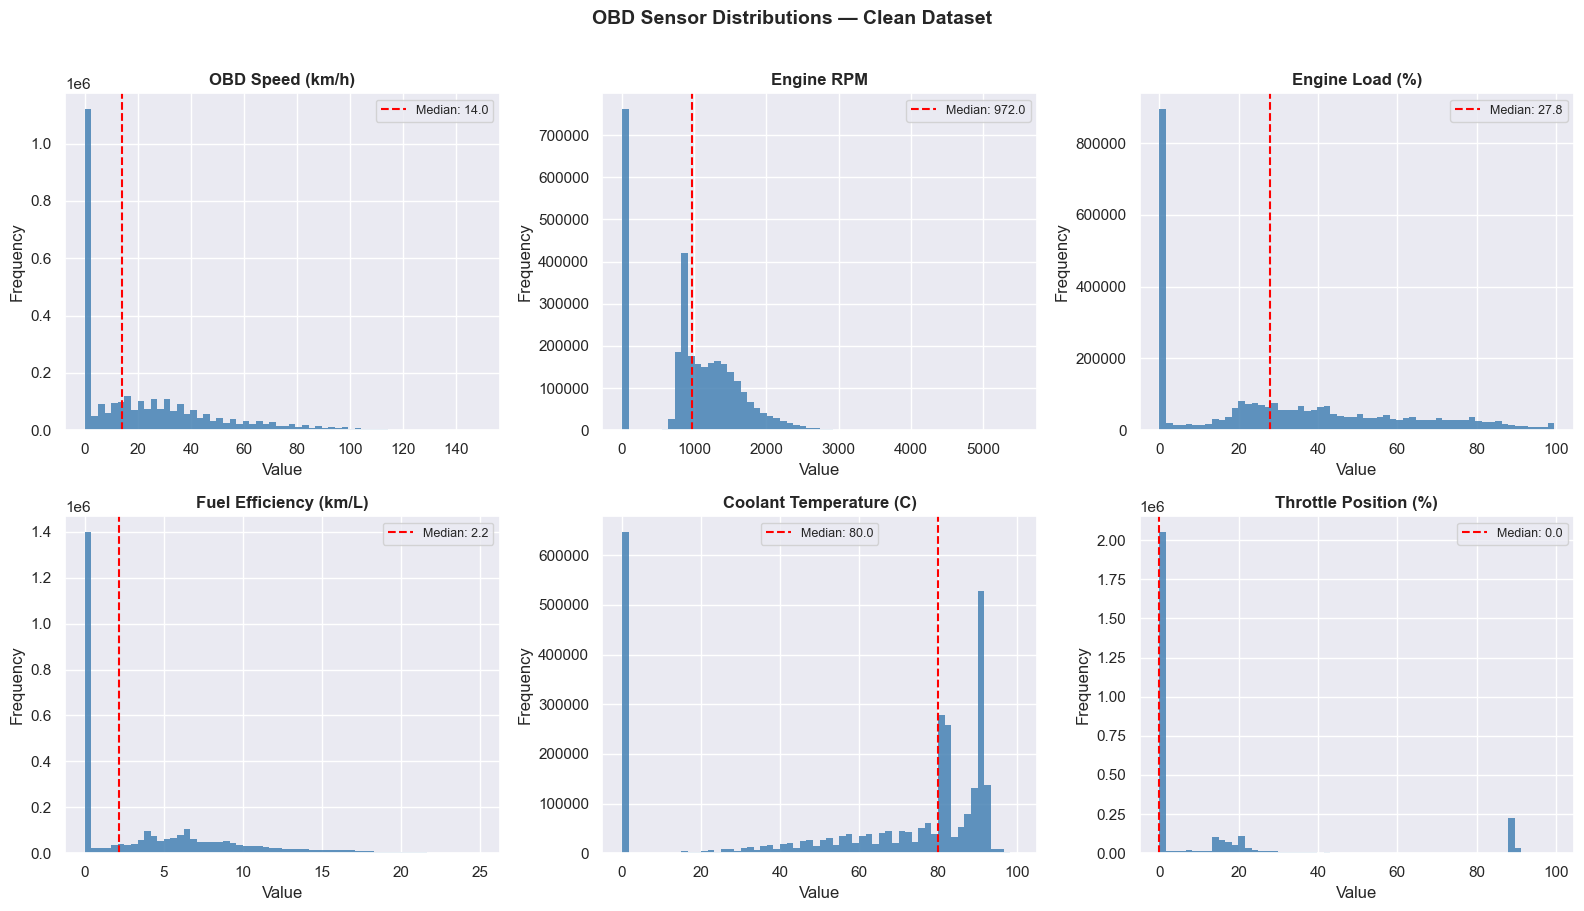

Saved -> outputs/01_sensor_distributions.png


In [51]:
plot_sensors = {k: v for k, v in {
    'speed' : 'OBD Speed (km/h)',
    'rpm'   : 'Engine RPM',
    'eLoad' : 'Engine Load (%)',
    'kpl'   : 'Fuel Efficiency (km/L)',
    'cTemp' : 'Coolant Temperature (C)',
    'tPos'  : 'Throttle Position (%)'
}.items() if k in df.columns}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, (col, label) in enumerate(plot_sensors.items()):
    data = df[col].dropna()
    axes[i].hist(data, bins=60, color='steelblue', edgecolor='none', alpha=0.85)
    axes[i].axvline(data.median(), color='red', linestyle='--', lw=1.5,
                    label=f'Median: {data.median():.1f}')
    axes[i].set_title(label, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    axes[i].legend(fontsize=9)

plt.suptitle('OBD Sensor Distributions — Clean Dataset', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/01_sensor_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> outputs/01_sensor_distributions.png')

## 4. Temporal Patterns

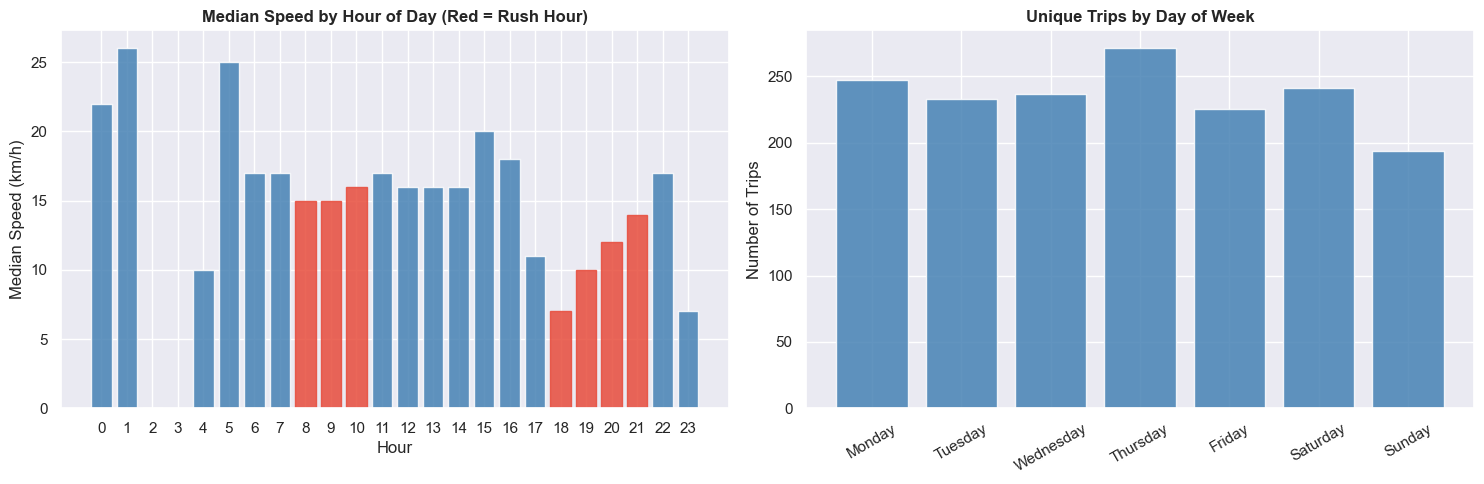

Saved -> outputs/02_temporal_patterns.png


In [52]:
df['hour']        = df['timeStamp'].dt.hour
df['day_of_week'] = df['timeStamp'].dt.day_name()

hourly = df.groupby('hour')['speed'].median()
rush   = list(range(7, 10)) + list(range(17, 21))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Median speed by hour — rush hours highlighted in red
bars = axes[0].bar(hourly.index, hourly.values, color='steelblue', alpha=0.85)
for i, bar in enumerate(bars):
    if i in rush:
        bar.set_color('#e74c3c')
axes[0].set_title('Median Speed by Hour of Day (Red = Rush Hour)', fontweight='bold')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Median Speed (km/h)')
axes[0].set_xticks(range(0, 24))

# Trip count by day of week
dow_order  = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_counts = df.groupby('day_of_week')['tripID'].nunique().reindex(dow_order, fill_value=0)
axes[1].bar(dow_counts.index, dow_counts.values, color='steelblue', alpha=0.85)
axes[1].set_title('Unique Trips by Day of Week', fontweight='bold')
axes[1].set_ylabel('Number of Trips')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../outputs/02_temporal_patterns.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> outputs/02_temporal_patterns.png')

## 5. Speed-Efficiency Map (per vehicle)

Groups sensor readings into speed zones and calculates average fuel efficiency (kpl) per zone.
Idle readings (speed <= 2 km/h) and zero kpl values are excluded to focus on active driving.
Vehicles with no KPL sensor data and Vehicle 7 (unreliable sensor) are excluded.

In [53]:
# Define speed zones in km/h
bins   = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 120, 150]
labels = ['0-10','10-20','20-30','30-40','40-50',
          '50-60','60-70','70-80','80-90','90-100','100-120','120+']

df['speed_zone'] = pd.cut(df['speed'], bins=bins, labels=labels, right=False)

# Exclude idle, zero kpl, no-kpl devices, and unreliable kpl devices
EXCLUDED_DEVICES = NO_KPL_DEVICES + UNRELIABLE_KPL_DEVICES
df_moving = df[
    (df['speed'] > 2) &
    (df['kpl'] > 0) &
    (~df['deviceID'].isin(EXCLUDED_DEVICES))
].copy()

# Calculate mean and median kpl per vehicle per speed zone
speed_map = df_moving.groupby(['deviceID', 'speed_zone'])['kpl'].agg(
    mean_kpl   = 'mean',
    median_kpl = 'median',
    count      = 'count'
).reset_index()

# Remove zones with fewer than 30 readings — statistically unreliable
speed_map = speed_map[speed_map['count'] >= 30]
speed_map['mean_kpl'] = speed_map['mean_kpl'].round(2)

print(f'Vehicles included : {df_moving["deviceID"].nunique()}')
print(f'Excluded devices  : {[int(d) for d in EXCLUDED_DEVICES]}')
print(f'Speed map entries : {len(speed_map)}')

Vehicles included : 8
Excluded devices  : [0, 1, 2, 4, 11, 14, 7]
Speed map entries : 90


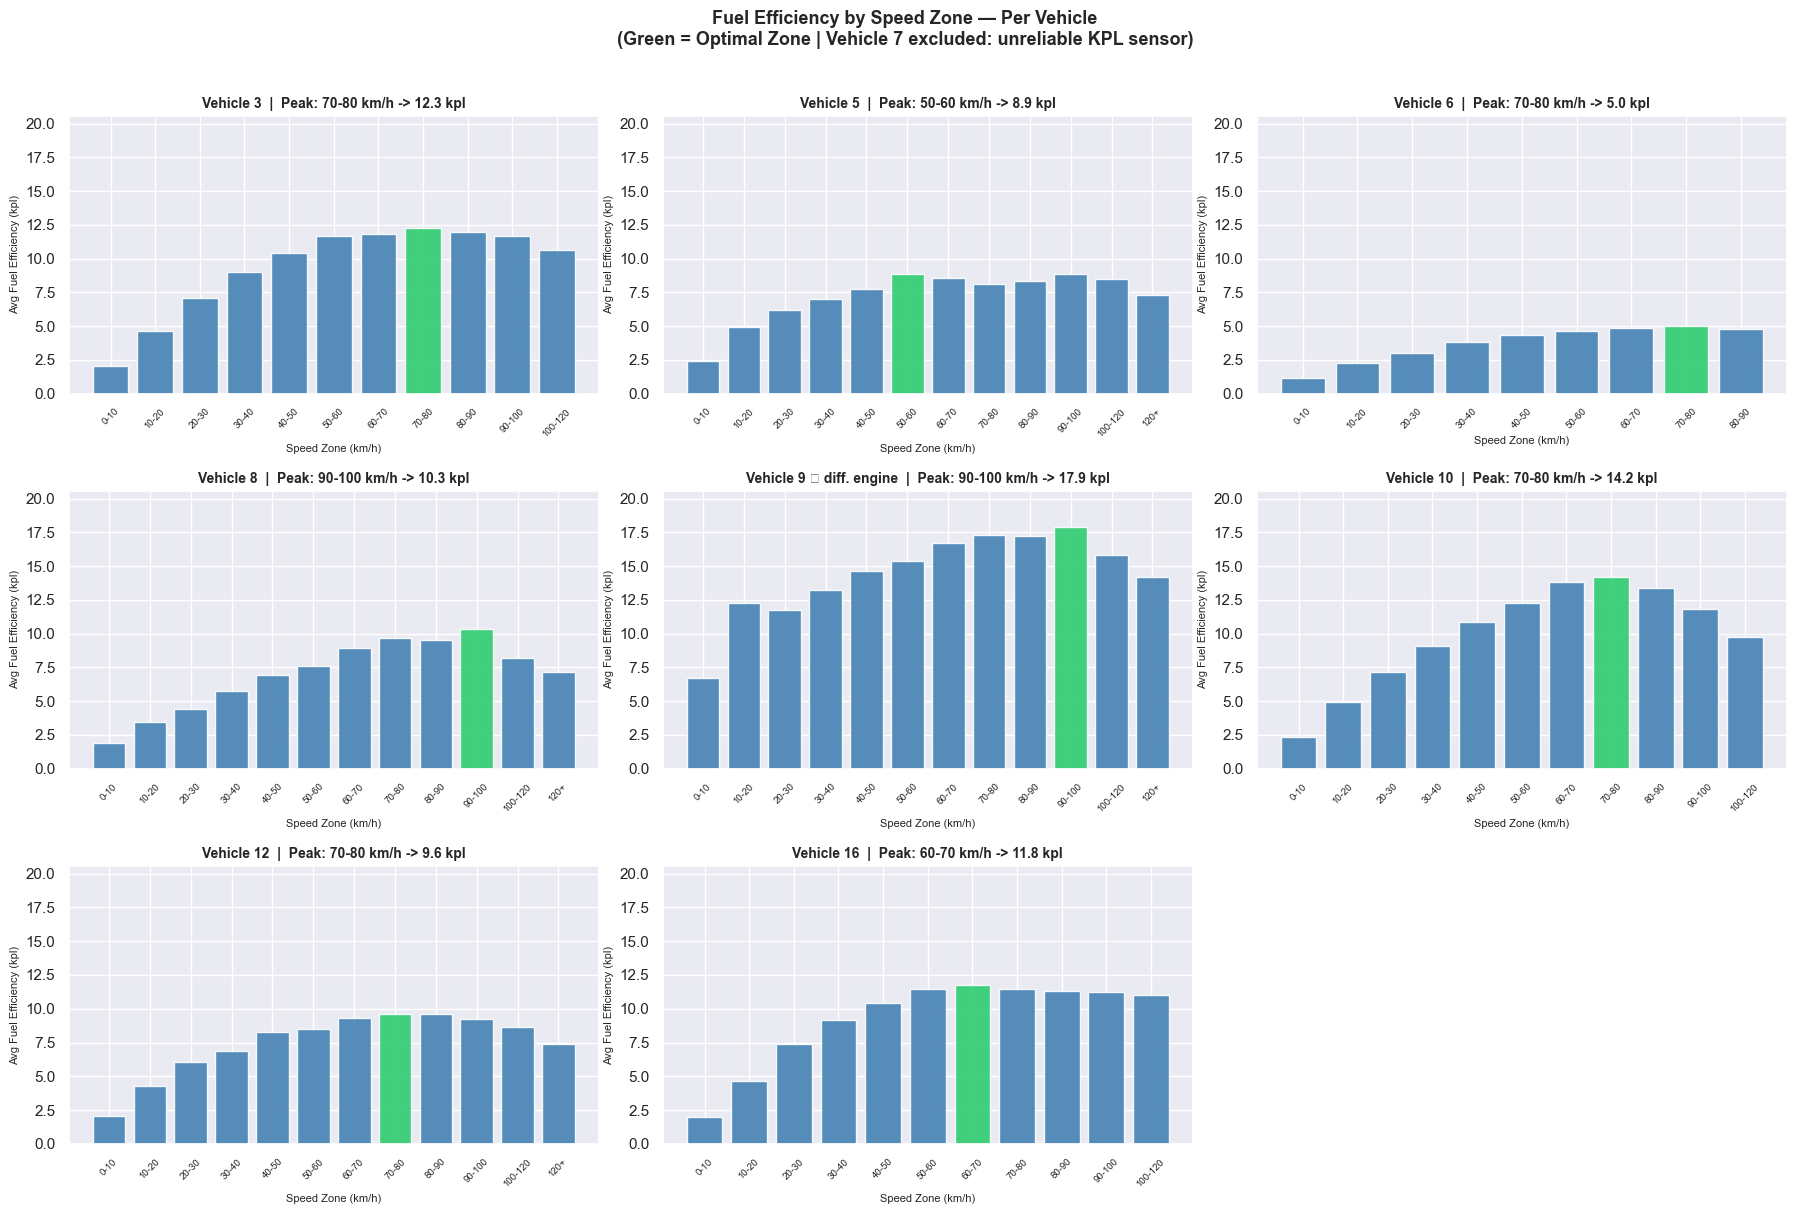

Saved -> outputs/03_speed_efficiency_map.png


In [54]:
# Per-vehicle speed-efficiency bar charts
devices = sorted(df_moving['deviceID'].dropna().unique())
n_cols  = 3
n_rows  = -(-len(devices) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, dev_id in enumerate(devices):
    ax       = axes[i]
    dev_data = speed_map[speed_map['deviceID'] == dev_id].copy()

    if dev_data.empty:
        continue

    # Identify the speed zone with highest average fuel efficiency
    best_idx  = dev_data['mean_kpl'].idxmax()
    best_zone = dev_data.loc[best_idx, 'speed_zone']
    best_kpl  = dev_data['mean_kpl'].max()

    # Highlight optimal zone in green
    colors = ['#2ecc71' if z == best_zone else 'steelblue'
              for z in dev_data['speed_zone']]

    # Add note for Vehicle 9 anomaly
    note = ' ⚠ diff. engine' if dev_id == 9.0 else ''

    ax.bar(dev_data['speed_zone'], dev_data['mean_kpl'],
           color=colors, edgecolor='white', alpha=0.9)
    ax.set_title(f'Vehicle {int(dev_id)}{note}  |  Peak: {best_zone} km/h -> {best_kpl:.1f} kpl',
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('Speed Zone (km/h)', fontsize=8)
    ax.set_ylabel('Avg Fuel Efficiency (kpl)', fontsize=8)
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.set_ylim(0, speed_map['mean_kpl'].max() * 1.15)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Fuel Efficiency by Speed Zone — Per Vehicle\n(Green = Optimal Zone | Vehicle 7 excluded: unreliable KPL sensor)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/03_speed_efficiency_map.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> outputs/03_speed_efficiency_map.png')

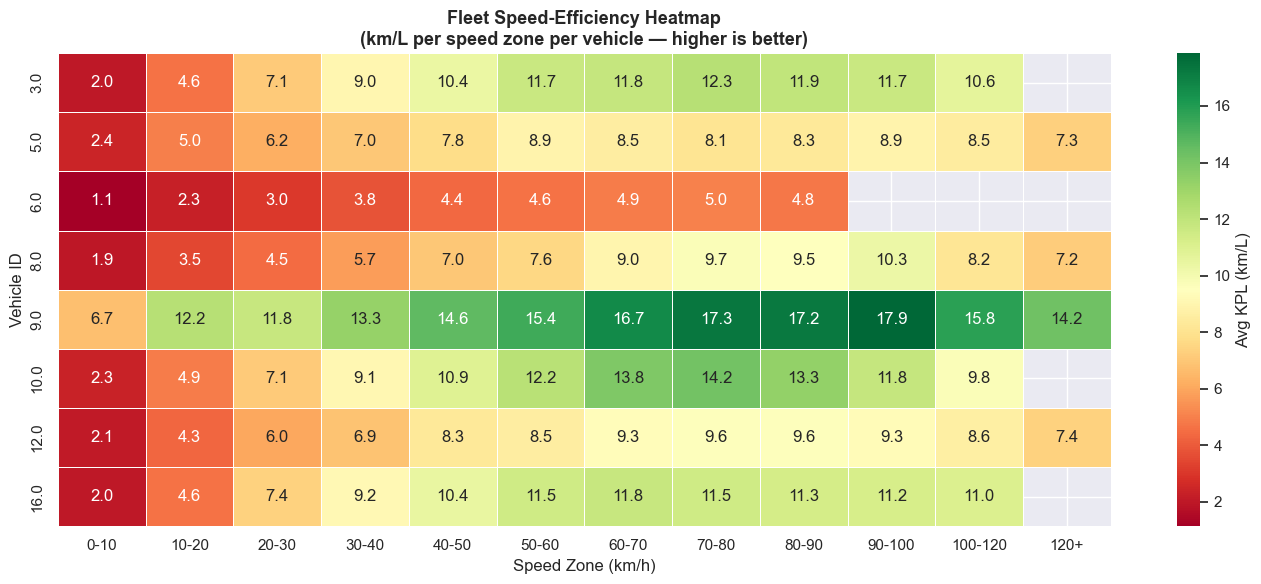

Saved -> outputs/03b_fleet_heatmap.png


In [55]:
# Fleet-wide heatmap — all valid vehicles vs all speed zones
heatmap_data = speed_map.pivot_table(
    index='deviceID', columns='speed_zone', values='mean_kpl'
)

plt.figure(figsize=(14, 6))
sns.heatmap(
    heatmap_data,
    annot=True, fmt='.1f',
    cmap='RdYlGn',
    linewidths=0.5,
    cbar_kws={'label': 'Avg KPL (km/L)'}
)
plt.title('Fleet Speed-Efficiency Heatmap\n(km/L per speed zone per vehicle — higher is better)',
          fontsize=13, fontweight='bold')
plt.xlabel('Speed Zone (km/h)')
plt.ylabel('Vehicle ID')
plt.tight_layout()
plt.savefig('../outputs/03b_fleet_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> outputs/03b_fleet_heatmap.png')

## 6. Fleet Fuel Consumption Summary

In [56]:
# Calculate time delta between consecutive readings within each trip
df_moving['time_diff_s'] = (
    df_moving.groupby(['deviceID','tripID'])['timeStamp']
    .diff()
    .dt.total_seconds()
)

# Cap gaps at 5 seconds to avoid inflating distance at trip boundaries
df_moving['time_diff_s'] = df_moving['time_diff_s'].clip(0, 5)

# Distance (km) = speed (km/h) / 3600 * time (seconds)
df_moving['dist_km'] = df_moving['speed'] / 3600 * df_moving['time_diff_s']

# Fuel consumed (L) = distance / efficiency
df_moving['fuel_L'] = df_moving['dist_km'] / df_moving['kpl'].replace(0, np.nan)

# Aggregate to trip level
trip_summary = df_moving.groupby(['deviceID','tripID']).agg(
    total_dist_km = ('dist_km',     'sum'),
    total_fuel_L  = ('fuel_L',      'sum'),
    avg_kpl       = ('kpl',         'mean'),
    avg_speed     = ('speed',       'mean'),
    max_speed     = ('speed',       'max'),
    avg_rpm       = ('rpm',         'mean'),
    duration_min  = ('time_diff_s', 'sum'),
).reset_index()

trip_summary['duration_min']  = (trip_summary['duration_min'] / 60).round(1)
trip_summary['total_dist_km'] = trip_summary['total_dist_km'].round(2)
trip_summary['total_fuel_L']  = trip_summary['total_fuel_L'].round(3)
trip_summary['avg_kpl']       = trip_summary['avg_kpl'].round(2)
trip_summary['avg_speed']     = trip_summary['avg_speed'].round(1)

# Remove trips that are too short or have unrealistic fuel values
trip_summary = trip_summary[
    (trip_summary['total_dist_km'] > 0.5) &
    (trip_summary['total_fuel_L']  < 200) &
    (trip_summary['total_fuel_L']  > 0)
].reset_index(drop=True)

print(f'Valid trips: {len(trip_summary)}')
trip_summary.head(5)

Valid trips: 1190


,deviceID,tripID,total_dist_km,total_fuel_L,avg_kpl,avg_speed,max_speed,avg_rpm,duration_min
0,3.0,2.0,71.31,8.926,8.58,54.8,100.0,1487.891048,78.4
1,3.0,3.0,0.72,0.123,6.34,20.2,37.0,1061.311024,2.3
2,3.0,4.0,0.76,0.163,4.83,15.1,36.0,1003.318436,3.1
3,3.0,6.0,0.84,0.176,5.12,16.4,39.0,1032.420330,3.3
4,3.0,9.0,0.65,0.175,3.82,14.8,34.0,1041.446541,2.7


In [57]:
# Fleet-level summary — one row per vehicle
fleet_summary = trip_summary.groupby('deviceID').agg(
    total_trips   = ('tripID',        'count'),
    total_dist_km = ('total_dist_km', 'sum'),
    total_fuel_L  = ('total_fuel_L',  'sum'),
    avg_speed     = ('avg_speed',     'mean'),
).reset_index()

# Overall efficiency: total distance / total fuel (more accurate than mean of trip means)
fleet_summary['overall_kpl'] = (
    fleet_summary['total_dist_km'] / fleet_summary['total_fuel_L']
).round(2)

fleet_summary = fleet_summary.sort_values('overall_kpl', ascending=False).reset_index(drop=True)

print('Fleet Summary — Ranked by Fuel Efficiency:')
print(fleet_summary.to_string(index=False))

Fleet Summary — Ranked by Fuel Efficiency:
 deviceID  total_trips  total_dist_km  total_fuel_L  avg_speed  overall_kpl
      9.0          147        1509.02       123.217  28.376190        12.25
     10.0          352        3470.51       397.992  29.265909         8.72
      3.0          123        1287.07       147.827  27.866667         8.71
     16.0           38         492.50        65.800  23.781579         7.48
     12.0          266        2805.48       448.880  24.943985         6.25
      5.0          222        1733.47       282.082  29.803153         6.15
      8.0           30         265.44        55.461  29.200000         4.79
      6.0           12         121.42        37.671  32.966667         3.22


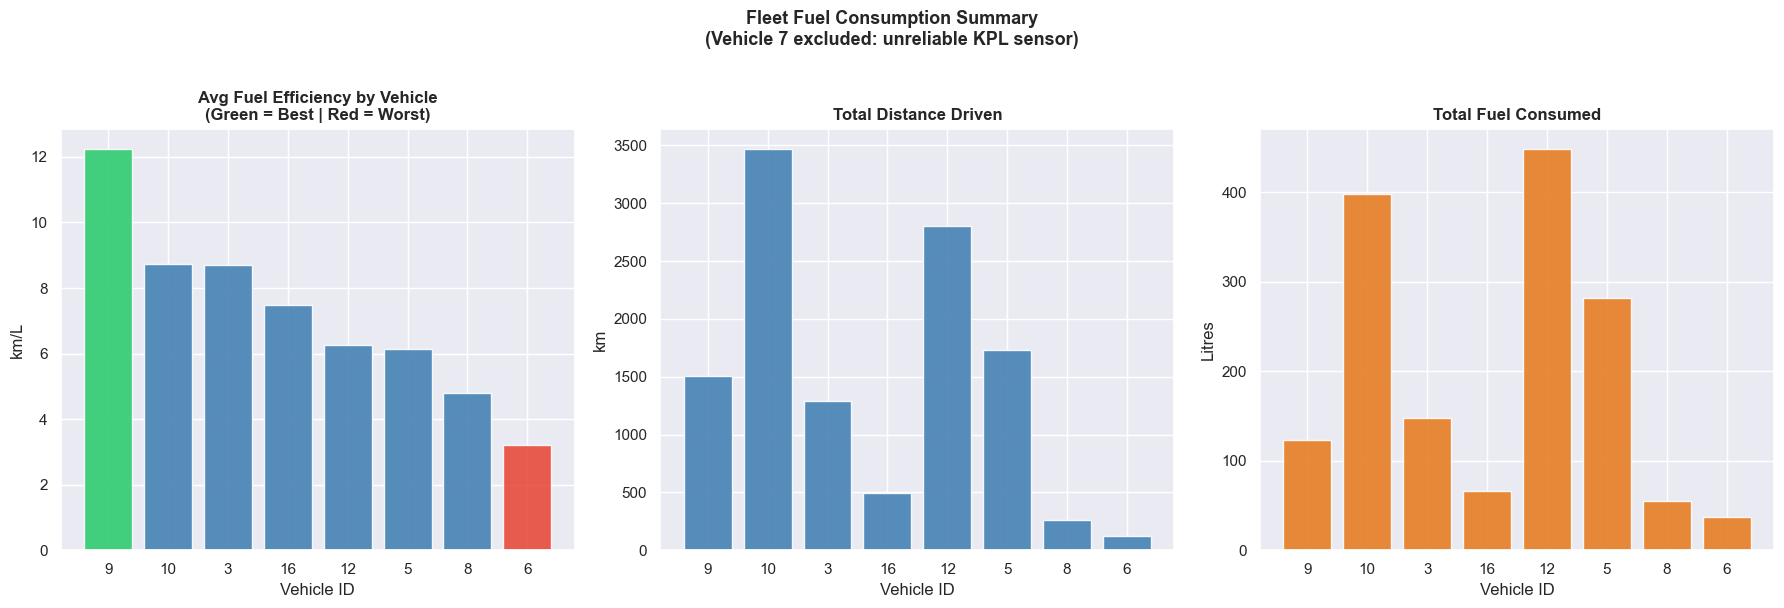

Saved -> outputs/04_fleet_fuel_summary.png


In [58]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
vids = fleet_summary['deviceID'].astype(int).astype(str)

# Avg fuel efficiency per vehicle — green = best, red = worst
colors = [
    '#2ecc71' if v == fleet_summary['overall_kpl'].max()
    else '#e74c3c' if v == fleet_summary['overall_kpl'].min()
    else 'steelblue'
    for v in fleet_summary['overall_kpl']
]
axes[0].bar(vids, fleet_summary['overall_kpl'], color=colors, edgecolor='white', alpha=0.9)
axes[0].set_title('Avg Fuel Efficiency by Vehicle\n(Green = Best | Red = Worst)', fontweight='bold')
axes[0].set_xlabel('Vehicle ID')
axes[0].set_ylabel('km/L')

# Total distance driven
axes[1].bar(vids, fleet_summary['total_dist_km'], color='steelblue', edgecolor='white', alpha=0.9)
axes[1].set_title('Total Distance Driven', fontweight='bold')
axes[1].set_xlabel('Vehicle ID')
axes[1].set_ylabel('km')

# Total fuel consumed
axes[2].bar(vids, fleet_summary['total_fuel_L'], color='#e67e22', edgecolor='white', alpha=0.9)
axes[2].set_title('Total Fuel Consumed', fontweight='bold')
axes[2].set_xlabel('Vehicle ID')
axes[2].set_ylabel('Litres')

plt.suptitle('Fleet Fuel Consumption Summary\n(Vehicle 7 excluded: unreliable KPL sensor)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/04_fleet_fuel_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> outputs/04_fleet_fuel_summary.png')

## 7. Gear Estimation Analysis (per vehicle)

Gear is estimated using the ratio of RPM to speed (gear_ratio = rpm / speed).
Higher ratio = lower gear (high RPM, low speed = 1st gear).
Lower ratio = higher gear (low RPM, high speed = 6th gear).

KMeans clustering is applied per vehicle so each vehicle is calibrated
to its own RPM and speed range — avoiding universal threshold assumptions.

⚠ Vehicle 7 is excluded due to intermittent KPL sensor data.
⚠ Vehicle 9 shows significantly higher KPL values — likely a different engine type or displacement.

In [59]:
# Active driving only — exclude idle and stall
df_gear = df[
    (df['speed'] > 2) &
    (df['rpm'] > 500) &
    (~df['deviceID'].isin(EXCLUDED_DEVICES))
].copy()

# Gear ratio proxy: higher = lower gear
df_gear['gear_ratio'] = df_gear['rpm'] / df_gear['speed']

def estimate_gears_kmeans(vehicle_df, n_gears=6):
    """
    Estimates gear labels per vehicle using KMeans on gear_ratio.
    Each vehicle is clustered independently — no universal thresholds.
    Cluster with highest gear_ratio centroid = Gear 1 (low speed, high RPM).
    """
    ratios = vehicle_df['gear_ratio'].dropna().values.reshape(-1, 1)

    if len(ratios) < n_gears * 10:
        return vehicle_df

    km = KMeans(n_clusters=n_gears, random_state=42, n_init=10)
    km.fit(ratios)

    # Map cluster index to gear name — highest centroid = Gear 1
    center_rank = {
        old: f'Gear {i+1}'
        for i, old in enumerate(
            sorted(range(n_gears), key=lambda x: km.cluster_centers_[x], reverse=True)
        )
    }

    vehicle_df = vehicle_df.copy()
    vehicle_df['est_gear'] = [
        center_rank[c]
        for c in km.predict(vehicle_df['gear_ratio'].fillna(0).values.reshape(-1, 1))
    ]
    return vehicle_df

# Apply per-vehicle — skip vehicles with no KPL data
gear_results = []
for dev_id, vehicle_df in df_gear.groupby('deviceID'):
    if len(vehicle_df) < 100:
        continue
    if vehicle_df['kpl'].sum() == 0:
        continue
    result = estimate_gears_kmeans(vehicle_df, n_gears=6)
    gear_results.append(result)

df_gear = pd.concat(gear_results).reset_index(drop=True)

gear_check = df_gear.groupby(['deviceID','est_gear'])[['speed','rpm','kpl']].mean().round(2)
print(gear_check.to_string())

                   speed      rpm    kpl
deviceID est_gear                       
3.0      Gear 1     3.05   993.56   1.02
         Gear 2     4.46   982.55   1.49
         Gear 3     7.79  1026.54   2.47
         Gear 4    15.48  1071.07   4.45
         Gear 5    27.76  1153.32   7.16
         Gear 6    66.00  1484.31  11.58
5.0      Gear 1     3.23   926.51   1.23
         Gear 2     4.84   926.60   1.86
         Gear 3     9.51  1180.64   2.77
         Gear 4    21.80  1463.12   4.65
         Gear 5    33.57  1510.01   6.82
         Gear 6    60.63  1715.80   9.16
6.0      Gear 1     3.02   843.33   0.60
         Gear 2     5.11   949.98   0.86
         Gear 3     8.85  1125.15   1.27
         Gear 4    20.07  1309.57   2.20
         Gear 5    40.11  1503.02   3.45
         Gear 6    58.63  1434.92   5.73
8.0      Gear 1     3.18   917.42   1.09
         Gear 2     4.93   968.12   1.56
         Gear 3     9.50  1258.73   2.19
         Gear 4    19.45  1619.51   3.34
         Gear 5 

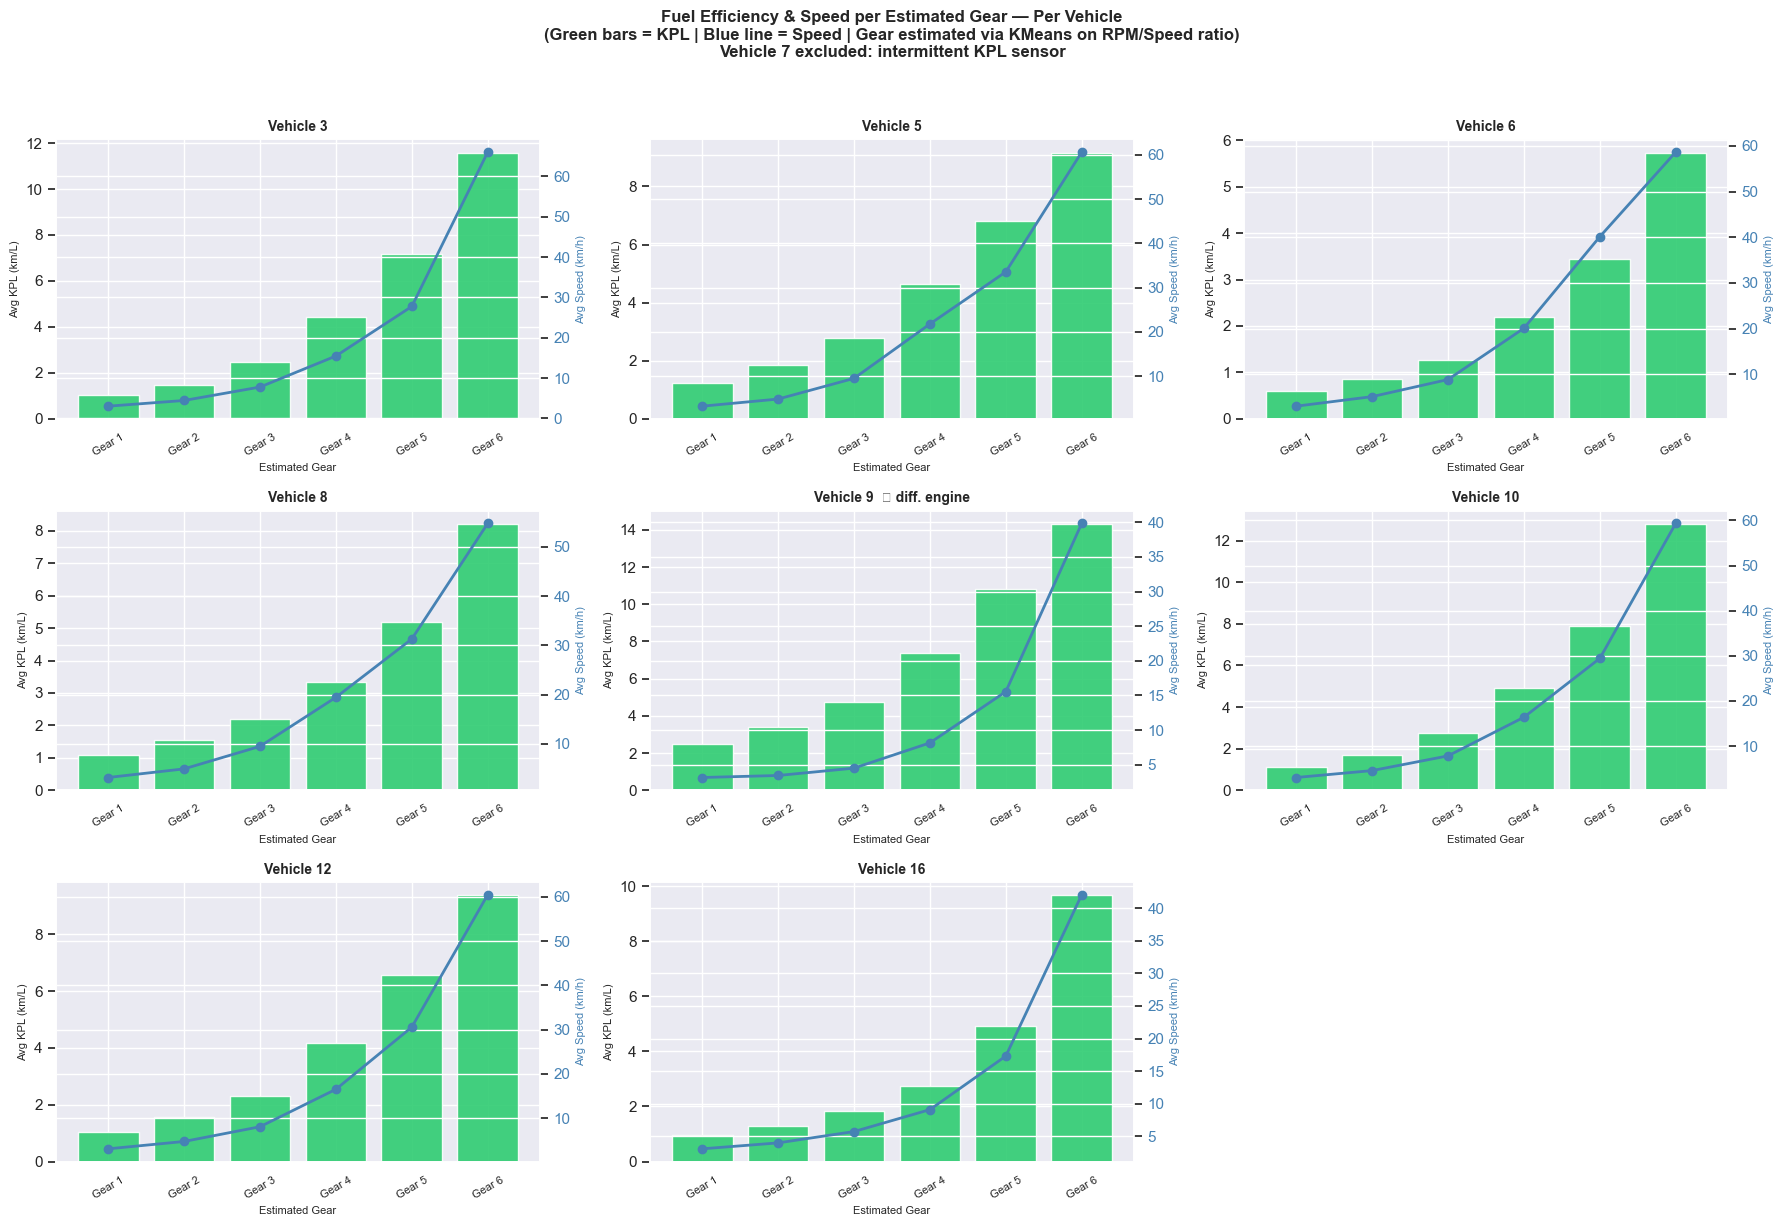

Saved -> outputs/05_gear_analysis.png


In [60]:
# Plot KPL and speed per estimated gear — per vehicle
gear_order = ['Gear 1','Gear 2','Gear 3','Gear 4','Gear 5','Gear 6']

gear_plot = df_gear.groupby(['deviceID','est_gear'])[['speed','rpm','kpl']].mean().round(2).reset_index()
gear_plot['est_gear'] = pd.Categorical(gear_plot['est_gear'], categories=gear_order, ordered=True)
gear_plot = gear_plot.sort_values(['deviceID','est_gear'])

devices_valid = sorted(df_gear['deviceID'].unique())
n_cols = 3
n_rows = -(-len(devices_valid) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, dev_id in enumerate(devices_valid):
    ax  = axes[i]
    dev = gear_plot[gear_plot['deviceID'] == dev_id]

    if dev.empty:
        continue

    # Green bars = KPL, blue line = speed
    ax.bar(dev['est_gear'], dev['kpl'],
           color='#2ecc71', edgecolor='white', alpha=0.9, label='KPL')

    ax2 = ax.twinx()
    ax2.plot(dev['est_gear'], dev['speed'],
             color='steelblue', marker='o', linewidth=2, label='Speed')
    ax2.set_ylabel('Avg Speed (km/h)', color='steelblue', fontsize=8)
    ax2.tick_params(axis='y', labelcolor='steelblue')

    # Add note for Vehicle 9
    note = '  ⚠ diff. engine' if dev_id == 9.0 else ''
    ax.set_title(f'Vehicle {int(dev_id)}{note}', fontweight='bold', fontsize=10)
    ax.set_xlabel('Estimated Gear', fontsize=8)
    ax.set_ylabel('Avg KPL (km/L)', fontsize=8)
    ax.tick_params(axis='x', rotation=30, labelsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    'Fuel Efficiency & Speed per Estimated Gear — Per Vehicle\n'
    '(Green bars = KPL | Blue line = Speed | Gear estimated via KMeans on RPM/Speed ratio)\n'
    'Vehicle 7 excluded: intermittent KPL sensor',
    fontsize=12, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('../outputs/05_gear_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> outputs/05_gear_analysis.png')

## 8. Data Quality Flags & Key Findings

In [61]:
best_vehicle  = fleet_summary.iloc[0]
worst_vehicle = fleet_summary.iloc[-1]

optimal_zones    = speed_map.loc[speed_map.groupby('deviceID')['mean_kpl'].idxmax(), 'speed_zone']
most_common_zone = optimal_zones.mode()[0]

print('=' * 62)
print('  DATA QUALITY FLAGS')
print('=' * 62)
print(f'  No KPL sensor data    : Vehicles {[int(d) for d in NO_KPL_DEVICES]}')
print(f'  Unreliable KPL sensor : Vehicle 7 (intermittent readings)')
print(f'  Anomalous KPL values  : Vehicle 9 (likely different engine type)')
print()
print('=' * 62)
print('  KEY FINDINGS')
print('=' * 62)
print(f'  Vehicles analysed     : {fleet_summary["deviceID"].nunique()}')
print(f'  Total valid trips     : {len(trip_summary):,}')
print(f'  Total distance        : {fleet_summary["total_dist_km"].sum():,.0f} km')
print(f'  Total fuel consumed   : {fleet_summary["total_fuel_L"].sum():,.1f} L')
print()
print(f'  Most efficient vehicle: Vehicle {int(best_vehicle["deviceID"])} -> {best_vehicle["overall_kpl"]:.1f} kpl')
print(f'  Least efficient       : Vehicle {int(worst_vehicle["deviceID"])} -> {worst_vehicle["overall_kpl"]:.1f} kpl')
print(f'  Efficiency gap        : {best_vehicle["overall_kpl"] - worst_vehicle["overall_kpl"]:.1f} kpl')
print()
print(f'  Fleet optimal speed   : {most_common_zone} km/h')
print(f'  Gear analysis method  : KMeans clustering on RPM/Speed ratio (per vehicle)')
print()
print('  -> Next: Tableau / Power BI Dashboard')
print('=' * 62)

# Export all processed datasets
trip_summary.to_csv('../data/processed/trip_summary.csv', index=False)
fleet_summary.to_csv('../data/processed/fleet_summary.csv', index=False)
speed_map.to_csv('../data/processed/speed_map.csv', index=False)
gear_plot.to_csv('../data/processed/gear_analysis.csv', index=False)
print('\nAll processed files saved to data/processed/ ✓')

  DATA QUALITY FLAGS
  No KPL sensor data    : Vehicles [0, 1, 2, 4, 11, 14]
  Unreliable KPL sensor : Vehicle 7 (intermittent readings)
  Anomalous KPL values  : Vehicle 9 (likely different engine type)

  KEY FINDINGS
  Vehicles analysed     : 8
  Total valid trips     : 1,190
  Total distance        : 11,685 km
  Total fuel consumed   : 1,558.9 L

  Most efficient vehicle: Vehicle 9 -> 12.2 kpl
  Least efficient       : Vehicle 6 -> 3.2 kpl
  Efficiency gap        : 9.0 kpl

  Fleet optimal speed   : 70-80 km/h
  Gear analysis method  : KMeans clustering on RPM/Speed ratio (per vehicle)

  -> Next: Tableau / Power BI Dashboard

All processed files saved to data/processed/ ✓
